In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [2]:
df = pd.read_csv("../preprocessing/cleaned_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (100000, 44)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,County,State,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Day,Hour,DayOfWeek
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,I-70 E,Dayton,Montgomery,OH,...,False,Night,Night,Night,Night,2016,2,8,5,Monday
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Brice Rd,Reynoldsburg,Franklin,OH,...,False,Night,Night,Night,Day,2016,2,8,6,Monday
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,State Route 32,Williamsburg,Clermont,OH,...,False,Night,Night,Day,Day,2016,2,8,6,Monday
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,I-75 S,Dayton,Montgomery,OH,...,False,Night,Day,Day,Day,2016,2,8,7,Monday
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Miamisburg Centerville Rd,Dayton,Montgomery,OH,...,False,Day,Day,Day,Day,2016,2,8,7,Monday


In [3]:
DROP_COLS = [
    "Start_Time",
    "End_Time",
    "Weather_Timestamp",
    "Street",
    "City",
    "County",
    "Zipcode",
    "Country",
    "Airport_Code",
    "Timezone",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "Year",
    "Day",
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

In [4]:
ENCODE_COLS = [
    "State",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "DayOfWeek"
]

le = LabelEncoder()

for col in ENCODE_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

In [5]:
BOOL_COLS = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop"
]

for col in BOOL_COLS:
    df[col] = df[col].astype(int)

In [6]:
df["Severity_Binary"] = df["Severity"].apply(
    lambda x: 0 if x <= 2 else 1
)

X = df.drop(columns=["Severity", "Severity_Binary"])
y = df["Severity_Binary"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (100000, 28)
Target Shape: (100000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### LOAD TRAINED MODEL

In [8]:
model = joblib.load("model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


### PREDICT TEST DATA 

In [9]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,1
4,0,1
5,0,0
6,0,1
7,1,1
8,1,1
9,1,1


### MODEL ACCURACY

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Model - Accuracy")
print(f"Accuracy Score : {accuracy:.4f}")
print(f"Accuracy       : {accuracy * 100:.2f}%")

print("\nInterpretation:")
print(f"The model correctly classified {accuracy * 100:.2f}% of the test samples.")

Random Forest Model - Accuracy
Accuracy Score : 0.8453
Accuracy       : 84.53%

Interpretation:
The model correctly classified 84.53% of the test samples.


### MODEL PRECISION SCORE

In [11]:
precision = precision_score(y_test, y_pred)

print("Random Forest Model - Precision")
print(f"Precision Score : {precision:.4f}")
print(f"Precision       : {precision * 100:.2f}%")

print("\nInterpretation:")
print(f"Out of all the accidents predicted as 'Severe', {precision * 100:.2f}% were actually severe.")

Random Forest Model - Precision
Precision Score : 0.8135
Precision       : 81.35%

Interpretation:
Out of all the accidents predicted as 'Severe', 81.35% were actually severe.


### RECALL SCORE

In [12]:
recall = recall_score(y_test, y_pred)

print("Random Forest Model - Recall")
print(f"Recall Score    : {recall:.4f}")
print(f"Recall          : {recall * 100:.2f}%")

print("\nInterpretation:")
print(f"Out of all the actual 'Severe' accidents, the model correctly identified {recall * 100:.2f}%.")

Random Forest Model - Recall
Recall Score    : 0.8501
Recall          : 85.01%

Interpretation:
Out of all the actual 'Severe' accidents, the model correctly identified 85.01%.


### F1 - SCORE

In [13]:
f1 = f1_score(y_test, y_pred)

print("Random Forest Model - F1 Score")
print(f"F1 Score        : {f1:.4f}")
print(f"F1 Score        : {f1 * 100:.2f}%")

print("\nInterpretation:")
print(f"The model achieved an F1-Score of {f1 * 100:.2f}%, indicating the overall balance between Precision and Recall.")

Random Forest Model - F1 Score
F1 Score        : 0.8314
F1 Score        : 83.14%

Interpretation:
The model achieved an F1-Score of 83.14%, indicating the overall balance between Precision and Recall.


### MODEL CLASSIFICATION REPORT

In [14]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Mild", "Severe"]
)

print("Random Forest Model - Classification Report")
print(report)

Random Forest Model - Classification Report
              precision    recall  f1-score   support

        Mild       0.87      0.84      0.86     11025
      Severe       0.81      0.85      0.83      8975

    accuracy                           0.85     20000
   macro avg       0.84      0.85      0.84     20000
weighted avg       0.85      0.85      0.85     20000



### CONFUSION MATRIX

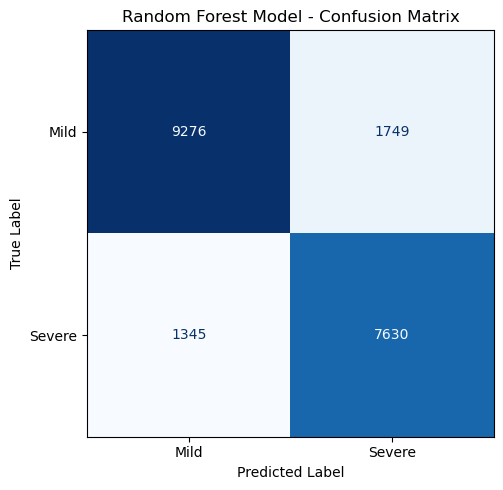

Confusion Matrix Values
[[9276 1749]
 [1345 7630]]


In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Mild", "Severe"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Random Forest Model - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Values")
print(cm)

### AUC SCORE

In [16]:
# Calculate the Area Under the ROC Curve (AUC)

# Get the probability of the positive class (Severe)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate AUC Score
auc = roc_auc_score(y_test, y_prob)

print("Random Forest Model - AUC Score")
print(f"AUC Score : {auc:.4f}")

print("\nInterpretation:")
print(f"The model achieved an AUC Score of {auc:.4f}, indicating its ability to distinguish between Mild and Severe accidents.")

Random Forest Model - AUC Score
AUC Score : 0.9183

Interpretation:
The model achieved an AUC Score of 0.9183, indicating its ability to distinguish between Mild and Severe accidents.


### ROC CURVE

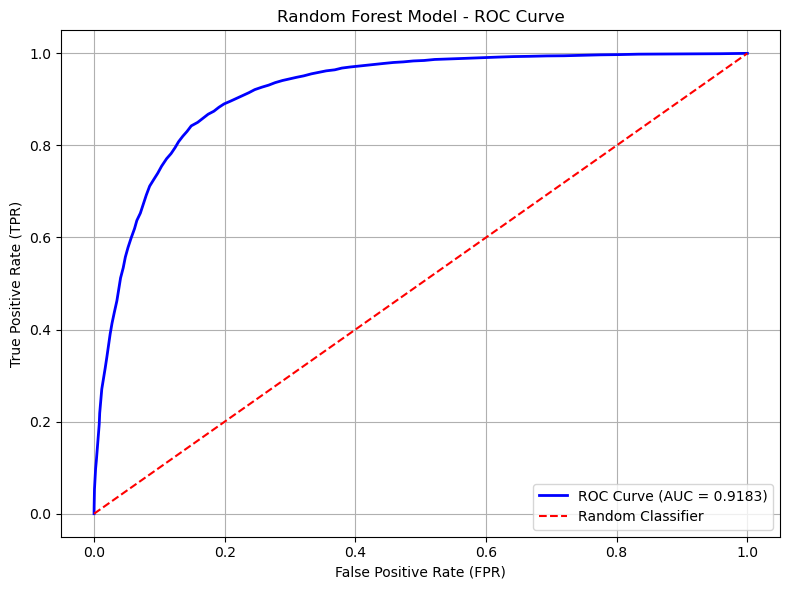

In [17]:
# Generate the ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"ROC Curve (AUC = {auc:.4f})"
)

# Reference line for a random classifier
plt.plot(
    [0, 1],
    [0, 1],
    color="red",
    linestyle="--",
    label="Random Classifier"
)

plt.title("Random Forest Model - ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()

# Save the figure
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

### FEATURE IMPORTANCE

C:\Users\HP Pavilion\AppData\Local\Temp\ipykernel_17612\3881908506.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


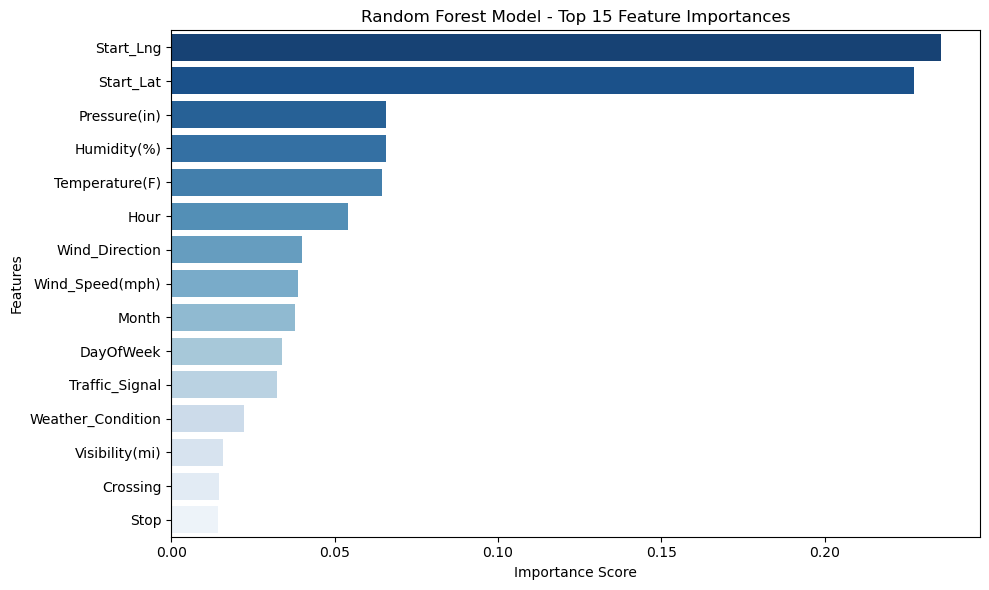

Top 15 Most Important Features
Start_Lng            0.235778
Start_Lat            0.227344
Pressure(in)         0.065772
Humidity(%)          0.065717
Temperature(F)       0.064662
Hour                 0.054040
Wind_Direction       0.039953
Wind_Speed(mph)      0.038802
Month                0.037904
DayOfWeek            0.034048
Traffic_Signal       0.032375
Weather_Condition    0.022217
Visibility(mi)       0.015864
Crossing             0.014504
Stop                 0.014313
dtype: float64


In [18]:
# Display the Top 15 Most Important Features

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="Blues_r"
)

plt.title("Random Forest Model - Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

# Save the figure
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()
# Print the importance score of the Top 15 features

print("Top 15 Most Important Features")
print(top_features)

## FINAL CONCLUSION

In [19]:
# Final Conclusion

print("FINAL CONCLUSION\n")

print(f"""
The Random Forest Classifier was successfully evaluated on the traffic accident dataset.

Performance Summary:
• Accuracy  : {accuracy * 100:.2f}%
• Precision : {precision * 100:.2f}%
• Recall    : {recall * 100:.2f}%
• F1-Score  : {f1 * 100:.2f}%
• AUC Score : {auc:.4f}

Conclusion:
• The model achieved an overall accuracy of {accuracy * 100:.2f}% on the test dataset.
• A precision of {precision * 100:.2f}% indicates that most accidents predicted as 'Severe' were actually severe.
• A recall of {recall * 100:.2f}% shows the model was able to identify a large proportion of actual severe accidents.
• The F1-Score of {f1 * 100:.2f}% demonstrates a good balance between Precision and Recall.
• The AUC Score of {auc:.4f} indicates the model has a strong ability to distinguish between Mild and Severe accidents.

Overall, the Random Forest model provides reliable performance for traffic accident severity prediction and can be used as a useful decision-support tool for identifying potentially severe accidents.
""")

FINAL CONCLUSION


The Random Forest Classifier was successfully evaluated on the traffic accident dataset.

Performance Summary:
• Accuracy  : 84.53%
• Precision : 81.35%
• Recall    : 85.01%
• F1-Score  : 83.14%
• AUC Score : 0.9183

Conclusion:
• The model achieved an overall accuracy of 84.53% on the test dataset.
• A precision of 81.35% indicates that most accidents predicted as 'Severe' were actually severe.
• A recall of 85.01% shows the model was able to identify a large proportion of actual severe accidents.
• The F1-Score of 83.14% demonstrates a good balance between Precision and Recall.
• The AUC Score of 0.9183 indicates the model has a strong ability to distinguish between Mild and Severe accidents.

Overall, the Random Forest model provides reliable performance for traffic accident severity prediction and can be used as a useful decision-support tool for identifying potentially severe accidents.



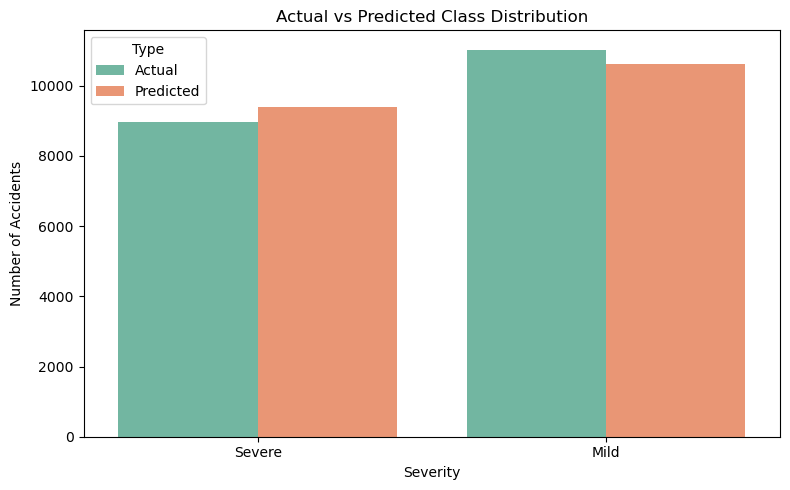

In [20]:
# Compare Actual vs Predicted Class Distribution

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison_long = comparison_df.melt(
    var_name="Type",
    value_name="Severity"
)

comparison_long["Severity"] = comparison_long["Severity"].map({
    0: "Mild",
    1: "Severe"
})

plt.figure(figsize=(8,5))

sns.countplot(
    data=comparison_long,
    x="Severity",
    hue="Type",
    palette="Set2"
)

plt.title("Actual vs Predicted Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

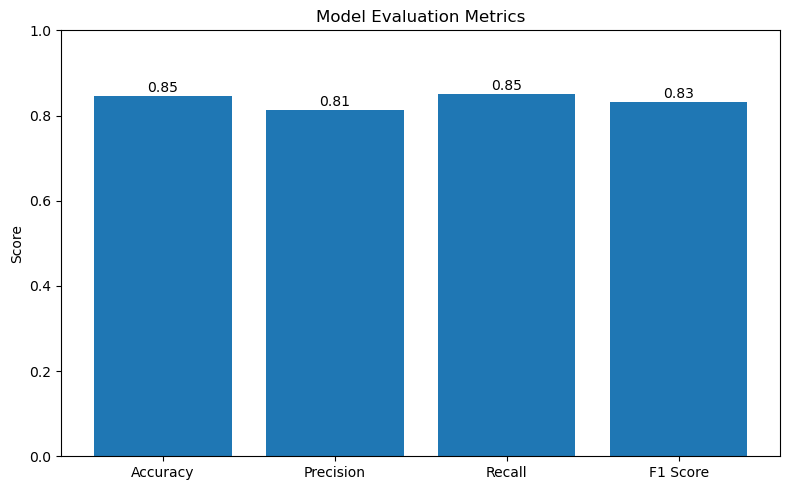

In [21]:
# Comparison of Evaluation Metrics

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

bars = plt.bar(metric_names, metric_values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Evaluation Metrics")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.01,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig("evaluation_metrics.png", dpi=300)

plt.show()

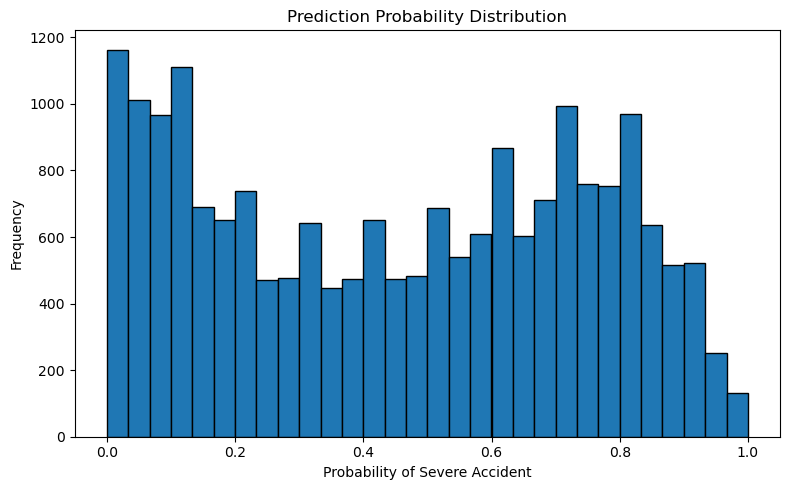

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=30,
    edgecolor="black"
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability of Severe Accident")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("prediction_probability.png", dpi=300)

plt.show()